# **Import Library**

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# **Load Data**

In [24]:
# Mengunduh dataset MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Menampilkan bentuk data
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


x_train shape: (60000, 28, 28), y_train shape: (60000,)
x_test shape: (10000, 28, 28), y_test shape: (10000,)


(jumlah data/total gambar, height, width)

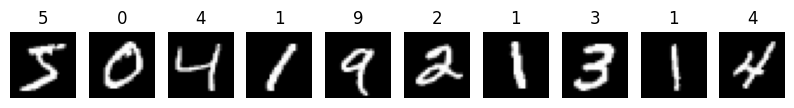

In [25]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.title(f'{y_train[i]}')
plt.show()

# **Pre-Processing Data**

In [26]:
# Normalisasi
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# mengubah rentang nilai piksel dari gambar, yang awalnya berada di antara 0 dan 255, menjadi rentang yang lebih kecil, yaitu antara 0 dan 1.

In [27]:
# Mengubah bentuk data menjadi 2D
x_train = x_train.reshape((x_train.shape[0], 28 * 28))  # 784 fitur
x_test = x_test.reshape((x_test.shape[0], 28 * 28))

# Mengubah bentuk (reshape) data dari format 3D menjadi format 2D agar sesuai untuk input ke model ANN

In [28]:
# Mengubah label ke dalam format one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# **Arsitektur ANN**

In [29]:
model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(784,))) # layer intput dan hidden layer pertama
# input untuk lapisan ini memiliki ukuran 28*28 atau 784
# 128 karena memiliki kapasitas yang cukup untuk menangkap berbagai pola dan fitur dalam data

model.add(layers.Dense(64, activation='relu')) # hidden layer kedua
# 64 agar model lebih fokus pada fitur yang lebih tinggi dan membantu dalam generalisasi, mengurangi risiko overfitting.

model.add(layers.Dense(10, activation='softmax')) # output layer
# 10 output karena Dataset MNIST memiliki 10 kelas (angka dari 0 hingga 9).
# jumlah neuron pada lapisan output diset sama dengan jumlah kelas. Setiap neuron di lapisan output akan mewakili satu kelas.

# **Compile Model**

In [30]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
# categorical_crossentropy digunakan untuk mengukur seberapa baik model dalam mengklasifikasikan kelas-kelas yang lebih dari dua (multi-class).

# **Fitting Model**

In [31]:
# Melatih model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Melatih model dengan menggunakan 10 ephochs atau 10 iterasi
# batch_size=32 digunakan agar model melihat 32 sampel sekaligus, menghitung loss, lalu memperbarui bobotnya
# validation_split=0.2 berarti 20% dari data train akan disisihkan untuk validasi, sementara 80% akan digunakan untuk pelatihan.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8630 - loss: 0.4656 - val_accuracy: 0.9617 - val_loss: 0.1358
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9643 - loss: 0.1169 - val_accuracy: 0.9644 - val_loss: 0.1096
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9759 - loss: 0.0776 - val_accuracy: 0.9663 - val_loss: 0.1073
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9828 - loss: 0.0548 - val_accuracy: 0.9711 - val_loss: 0.1030
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9861 - loss: 0.0418 - val_accuracy: 0.9750 - val_loss: 0.0836
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9886 - loss: 0.0336 - val_accuracy: 0.9724 - val_loss: 0.1018
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9747 - val_loss: 0.0971
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9928 - loss: 0.0210 -

# **Cek Akurasi**

In [32]:
# Evaluasi model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9709 - loss: 0.1293
Test accuracy: 0.9735


# **Confussion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


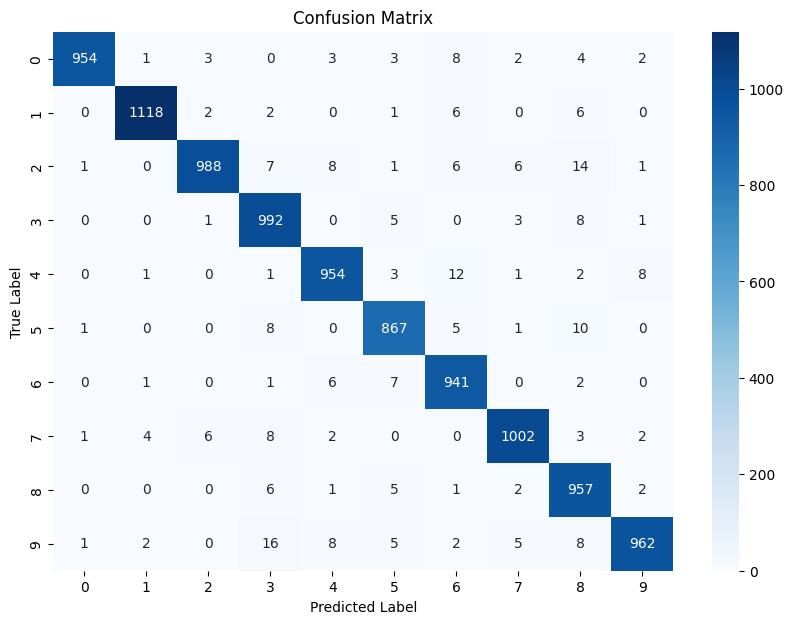

In [39]:
# Memprediksi
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# **Classification Report**

In [40]:
# Classification report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.96      0.98      0.97       958
           7       0.98      0.97      0.98      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

